# Data Initialization

Imports

In [1]:
# Standard Python
import collections
import random
import itertools
import io

#Data Science Python
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter, StrMethodFormatter
import pandas as pd
import seaborn as sns
import numpy as np
import scipy as sp
import scipy.spatial.distance as sp_dist
import altair as alt

In [11]:
df = pd.read_excel('/content/drive/MyDrive/_U of T Masters/AI for Chemical Engineering/CHE1148 Project/Large WTP Data.xlsx',
                 index_col='Date', parse_dates=['Date'])
parameters = df.columns.values.tolist()

# Data Cleaning

In [3]:
cut_off_date = "2015-03-01"

# Clean NaN values via forward fill. Backfill when forward fill fails
df_clean = df.ffill().bfill()
df_clean = df_clean[df_clean.index >= cut_off_date]

# Cut data without cleaning
df_cut = df[df.index >= cut_off_date]

# Remove Treated Water observations
col_to_remove = df.columns[df.columns.str.contains('\[TW\]')]

df_clean_noTW = df_clean.drop(col_to_remove, axis=1)

<>:11: SyntaxWarning: invalid escape sequence '\['
<>:11: SyntaxWarning: invalid escape sequence '\['
/tmp/ipython-input-230245514.py:11: SyntaxWarning: invalid escape sequence '\['
  col_to_remove = df.columns[df.columns.str.contains('\[TW\]')]


In [15]:
# View dataframes
print(parameters)
print("\nSliced Dataframe\n", df_cut.head())
print("\nCleaned Dataframe\n", df_clean.head())
print("\nCleaned Dataframe, no [TW]\n", df_clean_noTW.head())

['Year', 'Month', 'Day', '[Raw] Flow [m3/d]', '[Raw] Alkalinity as CaCO3 [mg/L]', '[Raw] Max Turbidity [NTU]', '[Raw] Min Turbidity [NTU]', '[Raw] Mean Turbidity [NTU]', '[Raw] E.Coli [cfu/100mL]', '[Raw] TC [cfu/100mL]', '[Raw] Temperature [°C]', '[Raw] DOC [mg/L]', '[Raw] TOC [mg/L]', '[Raw] pH [-]', '[Raw] TAN [mg/L]', '[Raw] NO3-N [mg/L]', '[Raw] NO2-N [mg/L]', '[Raw] MIB [ng/L]', '[Raw] Geosmin [ng/L]', '[Chem] Powdered Activated Carbon Dose [mg/L]', '[Chem] Alum Dose [mg/L]', '[Chem] Polyaluminum Chloride Dose [mg/L]', '[Chem] Polymer Dosage [mg/L]', '[Filt] Max Turbidity [NTU]', '[Filt] Mean Turbidity [NTU]', '[Filt] Total Runtime [h]', '[Filt] Backwash Volume [m3]', '[TW] Flow [m3/d]', '[TW] Alkalinity as CaCO3 [mg/L]', '[TW] Cl Dosage [mg/L]', '[TW] pH [-]', '[TW] Al [mg/L]', '[TW] Turbidity [NTU]', '[TW] HAA [ug/L]', '[TW] THM [ug/L]', '[TW] TAN [mg/L]', '[TW] NO3-N [mg/L]', '[TW] NO2-N [mg/L]', '[TW] E. Coli [cfu/100mL]', '[TW] MIB [ug/L]', '[TW] Geosmin [ug/L]']

Sliced Dat

In [10]:
# Confirm cleaning has not significantly changed data via KS test
key_parameter = '[Filt] Max Turbidity [NTU]'
alpha = 0.05

# Use KS Stat test to confirm both series come from the same distribution
ks_stat, pval = sp.stats.ks_2samp(df_clean[key_parameter].dropna(), df_cut[key_parameter].dropna())

print(f"KS-Stat = {ks_stat}")
print(f"P-Value = {pval}")

if pval < alpha:
  print("Reject Null Hypothesis: significant difference between dist.")
else:
  print("Do Not Reject Null Hypothesis: no significant difference between dist.")

KS-Stat = 0.15143534656922084
P-Value = 9.044388124942416e-52
Reject Null Hypothesis: significant difference between dist.


In [8]:
def investigate_dist_change(df_raw, df_clean):
    # List of all significantly different distributions based on K-S test

    # Initialze list of changed distributions and alpha value
    changed_dist = []
    alpha = 0.05

    # Iterate over each column and determine the KS Statistic
    for parameter in parameters:
      ks_stat, pval = sp.stats.ks_2samp(df_raw[key_parameter].dropna(), df_clean[key_parameter].dropna())
      if pval < alpha:
        #This means the Null Hypothesis is rejected: significant difference between dist
        changed_dist.append((parameter, f"P-Value: {pval}"))

    # If no items added to list, then distribution is the same.
    if changed_dist == []:
      changed_dist = "No distributions changed."

    return changed_dist

# Plotting Functions

In [6]:
def draw_time_series(data, plot_title, y_label, plot_series_list, save_fig=False):
    # Standardized Time Series Plot. Input list of plot parameters,

    # Check if plot_series_list is all valid parameters
    for series in plot_series_list:
      if series not in parameters:
        raise ValueError(f"'{series}' is not a valid parameter. Please choose from: {parameters}")

    # Generate plot colours
    colours = mpl.colormaps['plasma']
    colour_map = [colours(i/len(plot_series_list)) for i in range(len(plot_series_list))]

    # Draw line plot
    fig, ax = plt.subplots(figsize=(16.5, 10))

    chart = data[plot_series_list].plot(
      kind = 'line',
      figsize = (15,9),
      title = plot_title,
      xlabel = 'Date',
      ax = ax,
      ylabel = y_label,
      ylim = (0, None),
      color = colour_map
    )

    # Save image and return fig
    if save_fig: fig.savefig(plot_title.replace(' ', '_') + '_time_series.png')
    return fig

def draw_multiaxis_series(data, plot_title, y_label1, y_label2, plot_series_list1, plot_series_list2, save_fig=False):
    # Time Series Plot with 2 y axes. Input list of plot parameters

    # Check if plot_series_list is all valid parameters
    for series in plot_series_list1:
      if series not in parameters:
        raise ValueError(f"'{series}' is not a valid parameter. Please choose from: {parameters}")

    for series in plot_series_list2:
      if series not in parameters:
        raise ValueError(f"'{series}' is not a valid parameter. Please choose from: {parameters}")

    # Generate plot colours from a single colormap for all series
    total_series = len(plot_series_list1) + len(plot_series_list2)
    colours = mpl.colormaps['plasma']
    colour_map = [colours(i/total_series) for i in range(total_series)]

    # Draw line plot
    fig, ax1 = plt.subplots(figsize=(16.5, 10))

    # Create plot on axis 1
    data[plot_series_list1].plot(
      kind = 'line',
      figsize = (15,9),
      title = plot_title,
      xlabel = 'Date',
      ax = ax1,
      ylabel = y_label1,
      ylim = (0, None),
      color = colour_map[:len(plot_series_list1)]
    )

    # Create plot on axis 2
    ax2 = ax1.twinx()
    data[plot_series_list2].plot(
      kind = 'line',
      figsize = (15,9),
      title = plot_title,
      xlabel = 'Date',
      ax = ax2,
      legend = False,
      ylabel = y_label2,
      ylim = (0, None),
      color = colour_map[len(plot_series_list1):]
    )

    # Combine legends from both axes
    ax1_lines, ax1_labels = ax1.get_legend_handles_labels()
    ax2_lines, ax2_labels = ax2.get_legend_handles_labels()
    ax1.legend(ax1_lines + ax2_lines, ax1_labels + ax2_labels, loc='upper left')

    # Save image and return fig
    if save_fig: fig.savefig(plot_title.replace(' ', '_') + '_time_series.png')
    return fig

def draw_xy_graph(data, plot_title, x_series, y_series, x_label=None, y_label=None, save_fig=False):
    # Standardized Time Series Plot. Input list of plot parameters,

    # Check if plot_series_list is all valid parameters
    if x_series not in parameters:
      raise ValueError(f"'{x_series}' is not a valid parameter. Please choose from: {parameters}")
    if y_series not in parameters:
      raise ValueError(f"'{y_series}' is not a valid parameter. Please choose from: {parameters}")

    # Using defaul labels
    if x_label is None: x_label = x_series
    if y_label is None: y_label = y_series

    # Draw scatter plot
    fig, ax = plt.subplots(figsize=(16.5, 10))

    data.plot(
      kind = 'scatter',
      figsize = (15,9),
      title = plot_title,
      x = x_series,
      y = y_series,
      xlabel = x_label,
      ylabel = y_label,
      color = 'blue',
      marker = 'o',
      alpha = 0.5,
      ax = ax,
      ylim = (0, None),
      xlim = (0, None)
    )

    # Calculate regression line parameters
    slope, intercept, r_value, p_value, std_err = sp.stats.linregress(data[x_series], data[y_series])
    r_squared = r_value**2
    equation = f'y = {slope:.2f}x + {intercept:.2f} (R² = {r_squared:.2f})'

    # Draw regression line
    sns.regplot(
      data = data,
      x = x_series,
      y = y_series,
      scatter = False,
      ax = ax,
      line_kws=dict(color="red")
    )

    # Add a dummy plot for the regression line label in the legend
    ax.plot([], [], color='red', label=equation)
    ax.legend()

    # Save image and return fig
    if save_fig: fig.savefig(plot_title.replace(' ', '_') + '_time_series.png')
    return fig


def draw_heat_map(data, save_fig=False):
    # Create heat map plot

    # Create correlation matrix
    df_heat = data.drop(['Year', 'Month', 'Day'], axis=1)
    corr = df_heat.corr().round(2)

    mask = np.triu(np.ones_like(corr, dtype=bool),1)
    fig, ax = plt.subplots(figsize=(16, 10))
    fig = sns.heatmap(corr,vmin=-1, vmax=1, center=0, annot=True, cbar=True, cbar_kws=None, mask=mask)

    # Save image and return fig
    if save_fig: fig.savefig('heatmap.png')
    return fig

def draw_box_plot(data, ylabel, plot_series, save_fig=False):
    # Draw box plots
    month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    fig, (ax1,ax2) = plt.subplots(nrows=1,ncols=2,figsize=(16.5, 10))

    # make annual box plot
    sns.boxplot(
        data = data,
        x = 'Year',
        y = plot_series,
        ax = ax1
    )

    # make monthly box plot
    sns.boxplot(
        data = data,
        x = 'Month',
        y = plot_series,
        order = month_order,
        ax = ax2
    )

    ax1.set_title('Year-wise Box Plot for ' + ylabel)
    ax1.set_xlabel('Year')
    ax1.set_ylabel(ylabel)

    ax2.set_title('Month-wise Box Plot for ' + ylabel)
    ax2.set_xlabel('Month')
    ax2.set_ylabel(ylabel)

    # Save image and return fig
    if save_fig: fig.savefig(ylabel.replace(' ', '_') +'_box_plot.png')
    return fig

def draw_cumdist(data, ylabel, plot_series, title, save_fig=False):

    fig, ax = plt.subplots(figsize=(16.5, 10))

    sns.ecdfplot(
        data = data,
        y = plot_series,
        stat = "percent",
        ax = ax
    )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, None)
    ax.set_xlim(0, 100)

    # Save image and return fig
    if save_fig: fig.savefig(ylabel.replace(' ', '_') +'_box_plot.png')
    return fig

# Plots

<Axes: >

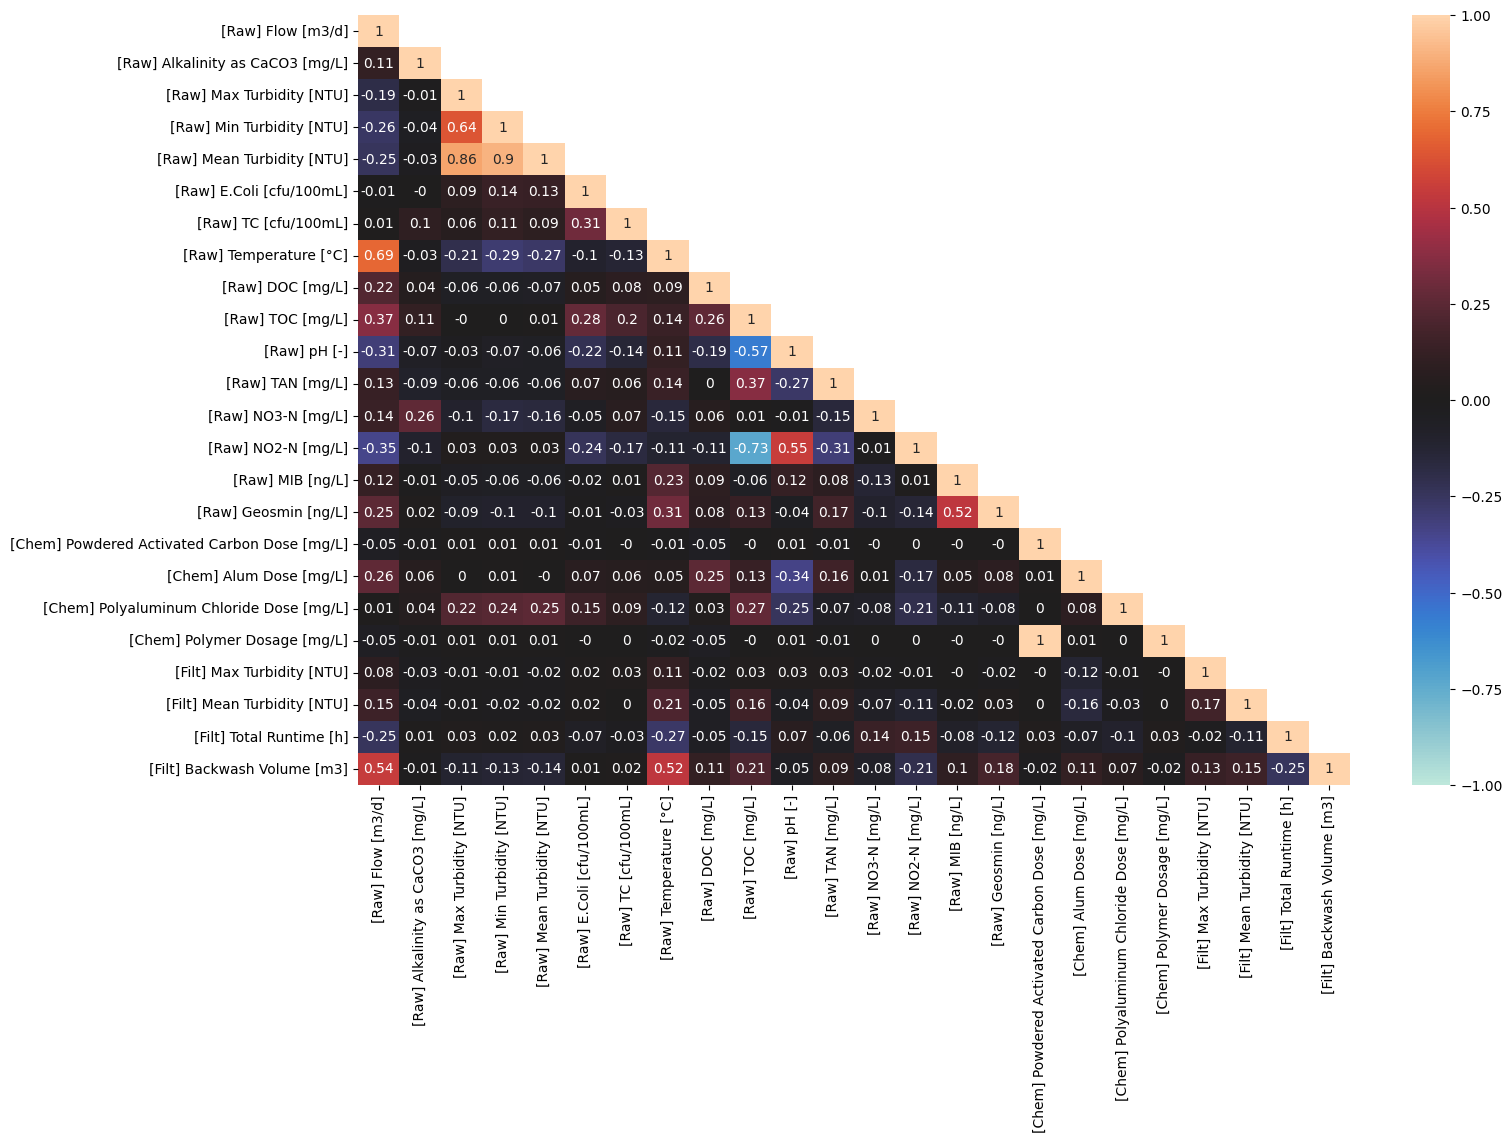

In [7]:
#draw_multiaxis_series(df_clean, 'Historical Raw Flow and Filter Turbidity', "Flow (m3/d)", "Turbidity (NTU)", ["[Raw] Flow [m3/d]"], ['[Filt] Mean Turbidity [NTU]','[Filt] Max Turbidity [NTU]'])
#draw_xy_graph(df_clean, "Flow vs Filt Turbidity", "[Raw] Flow [m3/d]", '[Filt] Max Turbidity [NTU]')
#draw_time_series(df_clean, "Historical Filter Turbidity", "Turbidity (NTU)", ['[Filt] Mean Turbidity [NTU]','[Filt] Max Turbidity [NTU]'])
draw_heat_map(df_clean_noTW)
#draw_box_plot(df_clean, "Filter Max Turbidity (NTU)", "[Filt] Max Turbidity [NTU]")
#draw_cumdist(df_clean, "Filter Max Turbidity (NTU)", "[Filt] Max Turbidity [NTU]", '')

In [ ]:
print(parameters)

['Year', 'Month', 'Day', '[Raw] Flow [m3/d]', '[Raw] Alkalinity as CaCO3 [mg/L]', '[Raw] Max Tubidity [NTU]', '[Raw] Min Tubidity [NTU]', '[Raw] Mean Tubidity [NTU]', '[Raw] E.Coli [cfu/100mL]', '[Raw] TC [cfu/100mL]', '[Raw] Temperature [°C]', '[Raw] DOC [mg/L]', '[Raw] TOC [mg/L]', '[Raw] pH [-]', '[Raw] TAN [mg/L]', '[Raw] NO3-N [mg/L]', '[Raw] NO2-N [mg/L]', '[Raw] MIB [ng/L]', '[Raw] Geosmin [ng/L]', '[Chem] Powdered Activated Carbon Dose [mg/L]', '[Chem] Alum Dose [mg/L]', '[Chem] Polyaluminum Chloride Dose [mg/L]', '[Chem] Polymer Dosage [mg/L]', '[Filt] Max Turbidity [NTU]', '[Filt] Mean Turbidity [NTU]', '[Filt] Total Runtime [h]', '[Filt] Backwash Volume [m3]', '[TW] Flow [m3/d]', '[TW] Alkalinity as CaCO3 [mg/L]', '[TW] Cl Dosage [mg/L]', '[TW] pH [-]', '[TW] Al [mg/L]', '[TW] Turbidity [NTU]', '[TW] HAA [ug/L]', '[TW] THM [ug/L]', '[TW] TAN [mg/L]', '[TW] NO3-N [mg/L]', '[TW] NO2-N [mg/L]', '[TW] E. Coli [cfu/100mL]', '[TW] MIB [ug/L]', '[TW] Geosmin [ug/L]']


# Statistics Functions

In [31]:
def find_top_correlations(df, n, target_col = None):
  # Returns list of top n most correlated parameters
  # When col entered, returns most correlated params with specific col

  # Create correlation matrix for target column and sort values
  if target_col is not None:
    # Ensure target column is within the dataframe parameters
    if target_col not in parameters:
      raise ValueError(f"'{target_col}' is not a valid parameter. Please choose from: {parameters}")

    corr_series = df.drop(['Year', 'Month', 'Day'], axis=1).corr()[target_col].drop([target_col]).sort_values(ascending=False).round(3)

  # Create general correlation matrix sort values
  else:
    # Create correlation matrix, then remove bottom triangle
    corr_matrix = df.drop(['Year', 'Month', 'Day'], axis=1).corr().round(3)
    corr_matrix = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool),1))

    # Stack correlation matrix and order from highest to lowest, renaming series
    corr_series = corr_matrix.stack().sort_values(ascending=False).rename("Correlation")

  top_list = pd.concat([corr_series.nlargest(n),corr_series.nsmallest(n)])

  return top_list

In [57]:
#corr_list = find_top_correlations(df_clean_noTW, 10, target_col = "[Filt] Max Turbidity [NTU]")
#corr_list.to_csv('data.csv', index=True)
#corr_list

df.drop(['Year'], axis=1).describe().round(3).to_csv('statistics_table_raw.csv', index=True)

# Data Processing Functions

In [ ]:
def lag_dataframe(df, lagtime):
  # Generate new dataframe that is lagged by n days, where n = lagtime
  # NOTE: the output df does not include data measured at T=0

  # Prepare empty list to hold all columns to be concatenated
  columns = []

  # Add columns for each lag date
  for i in range(1, lagtime + 1):
    columns.append(pd.Series(df.index.to_series().shift(i), name=f'Date T-{i}'))

  # Add columns for each lag data series
  parameters = df.columns.values.tolist()
  for i in range(1, lagtime + 1):
    for parameter in parameters:
      columns.append(pd.Series(df[parameter].shift(i), name=f'{parameter} at T-{i}'))

  # Concatenate all collected Series into a single DataFrame
  lagged_df = pd.concat(columns, axis=1)

  # Set index and rename for clarity, as it represents current date
  lagged_df.index = df.index
  lagged_df.index.name = 'Date T0'

  return lagged_df

def time_since_obs(df):
    # Create mask where:
    # value is 0 when data is available
    # value is previous value + 1 when NaN

    return df.apply(
      lambda col: col.isna().groupby(col.notna().cumsum()).cumsum()
    )